# 05 — PCA: reducción de dimensionalidad y visualización de clusters

## 1. Contexto

El modelo de clustering desarrollado en este proyecto segmenta los vinos utilizando 18 variables numéricas previamente transformadas y escaladas durante la fase de preprocesamiento.

Aunque este enfoque permite obtener agrupaciones consistentes, resulta imposible interpretar visualmente un espacio de 18 dimensiones.

Para facilitar el análisis utilizaremos **PCA (Principal Component Analysis)**, una técnica de reducción de dimensionalidad que proyecta la información en un espacio de menor dimensión conservando la mayor parte posible de la variabilidad original.

En este notebook utilizaremos PCA para:

- Analizar cuánta información conserva cada componente principal.
- Reducir las 18 variables del clustering a dos componentes principales.
- Representar gráficamente los vinos mediante PC1 y PC2.
- Visualizar los 8 clusters obtenidos con K-Means.
- Evaluar la separación entre clusters y detectar posibles solapamientos o vinos atípicos.
- Interpretar qué variables contribuyen con mayor peso a los componentes principales.

> **Importante:** PCA no genera los clusters. Los clusters ya fueron obtenidos previamente mediante K-Means. En este notebook PCA se utiliza únicamente como herramienta de análisis, visualización e interpretación.

## 2. Importación de librerías

En esta sección importamos las librerías necesarias para trabajar con los datos y aplicar el análisis de componentes principales.

Las utilizaremos para:

- Cargar y manipular el dataset.
- Aplicar PCA sobre las variables del clustering.
- Crear visualizaciones que faciliten la interpretación de los resultados.
- Analizar la contribución de cada componente principal.

In [1]:
# Manipulación de datos en formato tabular
import pandas as pd

# Operaciones numéricas
import numpy as np

# Implementación de PCA
from sklearn.decomposition import PCA

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Configuración general de gráficos
sns.set_theme(style="whitegrid")

# Mostrar todas las columnas cuando sea necesario
pd.set_option("display.max_columns", None)

## 3. Carga del dataset

El punto de partida de este análisis será el dataset generado durante la fase de preprocesamiento del proyecto.

Este archivo contiene tanto la información original de los vinos como todas las transformaciones realizadas previamente (codificación de variables categóricas, creación de nuevas variables y escalado). Es el mismo conjunto de datos que se utilizó para entrenar el modelo de clustering.

Antes de aplicar PCA realizaremos una comprobación básica para verificar que el dataset se ha cargado correctamente y conocer su estructura general.

> En las siguientes secciones seleccionaremos únicamente las variables escaladas utilizadas durante el entrenamiento del modelo de clustering.

In [2]:
# Ruta al dataset generado durante el preprocesamiento
DATA_PATH = "../data/processed/wines_SPA_model_ready.csv"

# Cargamos el dataset que servirá como punto de partida para el análisis
df = pd.read_csv(DATA_PATH)

print("✅ Dataset cargado correctamente.")

✅ Dataset cargado correctamente.


## 4. Comprobación de la estructura del dataset

Antes de seleccionar las variables del PCA, revisamos de forma breve la estructura general del archivo cargado.

Esta comprobación nos permitirá confirmar:

- El número de vinos disponibles.
- El número total de variables.
- Los tipos de datos presentes en el dataset.
- Una muestra de las primeras filas.

No repetiremos aquí el análisis de nulos, duplicados o distribuciones, ya que esas validaciones corresponden a las fases de limpieza, EDA y preprocesamiento.

In [3]:
# Dimensiones generales del dataset
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

# Información resumida sobre columnas y tipos de datos
df.info()

Número de filas: 2024
Número de columnas: 43
<class 'pandas.DataFrame'>
RangeIndex: 2024 entries, 0 to 2023
Data columns (total 43 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   winery                               2024 non-null   str    
 1   wine_name                            2024 non-null   str    
 2   year                                 2024 non-null   int64  
 3   rating                               2024 non-null   float64
 4   region                               2024 non-null   str    
 5   price_euros                          2024 non-null   float64
 6   grape_variety                        2024 non-null   str    
 7   wine_ageing                          2024 non-null   int64  
 8   service_temperature                  2024 non-null   str    
 9   quality_price_ratio                  2024 non-null   float64
 10  luxury_category                      2024 non-null   int64  
 

## 5. Selección de variables para PCA

Para garantizar que la representación obtenida mediante PCA sea coherente con el modelo de clustering, utilizaremos exactamente las mismas variables empleadas durante el entrenamiento de K-Means.

El clustering selecciona todas las columnas cuyo nombre termina en `_scaled`. Estas variables ya fueron transformadas y estandarizadas durante el preprocesamiento, por lo que no es necesario aplicar un nuevo escalado.

Mantener la misma selección y el mismo orden de columnas es fundamental: cualquier diferencia haría que el PCA representara un espacio distinto al utilizado para formar los clusters.

In [4]:
# Seleccionamos exactamente las mismas variables utilizadas por el clustering
scaled_cols = [col for col in df.columns if col.endswith("_scaled")]

# Construimos la matriz de entrada para PCA conservando el orden de las columnas
X = df[scaled_cols]

print(f"Número de variables seleccionadas: {X.shape[1]}")
print(f"Número de vinos: {X.shape[0]}")

Número de variables seleccionadas: 18
Número de vinos: 2024


## 6. Ajuste inicial del modelo PCA

Antes de reducir la dimensionalidad a dos componentes, ajustaremos un modelo PCA utilizando todas las variables seleccionadas.

Este primer ajuste nos permitirá conocer cuánta variabilidad del conjunto de datos explica cada componente principal y decidir posteriormente cuántos componentes conservar.

En esta fase no estamos reduciendo todavía la información; únicamente analizamos cómo se distribuye la variabilidad entre los distintos componentes.

In [5]:
# Ajustamos PCA conservando todos los componentes
pca = PCA()

# Entrenamos el modelo sobre la misma matriz utilizada por el clustering
pca.fit(X)

print("✅ Modelo PCA ajustado correctamente.")

✅ Modelo PCA ajustado correctamente.


## 7. Varianza explicada por los componentes principales

Una vez ajustado el modelo, analizaremos cuánta información conserva cada componente principal.

La **varianza explicada** indica qué porcentaje de la variabilidad total de los datos queda representado por cada componente.

Este análisis nos permitirá:

- Identificar los componentes más relevantes.
- Evaluar cómo se distribuye la información entre ellos.
- Decidir cuántos componentes resultan suficientes para representar la estructura del conjunto de datos.

In [6]:
# Calculamos la varianza explicada por cada componente principal
explained_variance = pca.explained_variance_ratio_

# Creamos una tabla resumen
variance_df = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Varianza explicada": explained_variance,
    "Porcentaje (%)": explained_variance * 100
})

# Redondeamos para facilitar la lectura
variance_df["Varianza explicada"] = variance_df["Varianza explicada"].round(4)
variance_df["Porcentaje (%)"] = variance_df["Porcentaje (%)"].round(2)

variance_df

,Componente,Varianza explicada,Porcentaje (%)
0,PC1,0.3119,31.19
1,PC2,0.1764,17.64
2,PC3,0.0945,9.45
3,PC4,0.0863,8.63
4,PC5,0.0799,7.99
5,PC6,0.0728,7.28
6,PC7,0.0671,6.71
7,PC8,0.0444,4.44
8,PC9,0.0360,3.60
9,PC10,0.0204,2.04


## 8. Visualización de la varianza explicada

La tabla anterior muestra la contribución individual de cada componente principal, pero una representación gráfica facilita mucho más su interpretación.

En esta sección visualizaremos:

- La varianza explicada por cada componente de forma individual.
- La varianza acumulada conforme se incorporan nuevos componentes.

Estos gráficos nos ayudarán a evaluar cuánta información conserva cada representación.

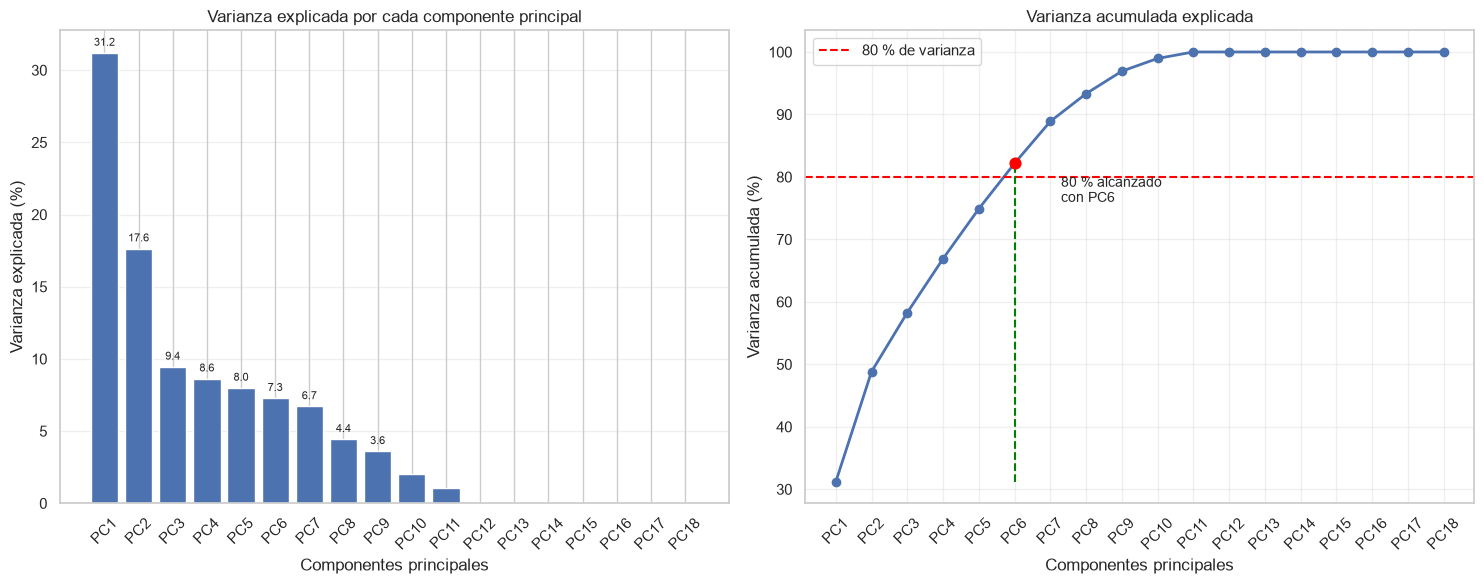

In [7]:
# Calculamos la varianza acumulada
variance_acum = np.cumsum(variance_df["Porcentaje (%)"])

# Identificamos el primer componente que supera el 80 % de varianza acumulada
component_80 = np.argmax(variance_acum >= 80)

# Creamos una figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =====================================================
# Gráfico 1: Varianza explicada por componente
# =====================================================

bars = axes[0].bar(
    variance_df["Componente"],
    variance_df["Porcentaje (%)"]
)

axes[0].set_title("Varianza explicada por cada componente principal")
axes[0].set_xlabel("Componentes principales")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

# Mostramos el porcentaje únicamente en los componentes más relevantes
for bar, value in zip(bars, variance_df["Porcentaje (%)"]):
    if value >= 3:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.5,
            f"{value:.1f}",
            ha="center",
            fontsize=8
        )

# =====================================================
# Gráfico 2: Varianza acumulada
# =====================================================

axes[1].plot(
    variance_df["Componente"],
    variance_acum,
    marker="o",
    linewidth=2
)

# Línea horizontal que marca el umbral del 80 %
axes[1].axhline(
    y=80,
    color="red",
    linestyle="--",
    label="80 % de varianza"
)

# Línea vertical limitada hasta el punto donde se supera el 80 %
axes[1].vlines(
    x=component_80,
    ymin=variance_acum.min(),
    ymax=variance_acum[component_80],
    colors="green",
    linestyles="--"
)

# Resaltamos el punto donde se supera el 80 %
axes[1].scatter(
    component_80,
    variance_acum[component_80],
    color="red",
    s=60,
    zorder=5
)

# Añadimos una anotación explicativa
axes[1].annotate(
    f"80 % alcanzado\ncon {variance_df.loc[component_80, 'Componente']}",
    xy=(component_80, variance_acum[component_80]),
    xytext=(component_80 + 1.3, 76),
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    ),
    fontsize=10,
    ha="left"
)

axes[1].set_title("Varianza acumulada explicada")
axes[1].set_xlabel("Componentes principales")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretación

El primer componente principal (**PC1**) concentra aproximadamente un **31,2 %** de la variabilidad total del conjunto de datos, mientras que el segundo componente (**PC2**) añade un **17,6 %** adicional. En conjunto, ambos componentes representan cerca del **49 %** de la información disponible.

La curva de varianza acumulada muestra que es necesario conservar los **seis primeros componentes principales** para superar el **80 %** de la variabilidad del conjunto de datos. Esto indica que la información se encuentra distribuida entre varias variables y no está concentrada únicamente en los dos primeros componentes.

Además, se observa que a partir del componente **PC12** la varianza explicada es prácticamente nula. Esto sugiere que parte de las variables utilizadas contienen información redundante o altamente correlacionada, por lo que los últimos componentes apenas aportan información adicional.

En este notebook utilizaremos únicamente **dos componentes principales** porque el objetivo del PCA es **visualizar e interpretar los clusters obtenidos mediante K-Means** en un espacio bidimensional. Aunque dos componentes no conservan toda la información del conjunto de datos, sí permiten representar de forma clara la estructura general de los grupos identificados por el modelo.

## 9. Proyección de los datos sobre los dos primeros componentes

Una vez analizada la varianza explicada, reduciremos la dimensionalidad del conjunto de datos a **dos componentes principales**.

Esta transformación permite representar cada vino mediante dos nuevas variables (`PC1` y `PC2`) que conservan la mayor cantidad posible de información.

El objetivo no es sustituir las variables originales, sino obtener una representación bidimensional que facilite la visualización e interpretación de los clusters generados por K-Means.

In [8]:
# Creamos un nuevo modelo PCA con dos componentes principales
pca_2d = PCA(n_components=2)

# Transformamos la matriz de características
X_pca = pca_2d.fit_transform(X)

# Creamos un DataFrame con las nuevas coordenadas
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(f"Número de vinos transformados: {pca_df.shape[0]}")
print(f"Número de componentes: {pca_df.shape[1]}")

pca_df.head()

Número de vinos transformados: 2024
Número de componentes: 2


,PC1,PC2
0,2.844821,2.523947
1,2.331943,1.814237
2,2.411796,1.843086
3,2.813513,2.522250
4,2.895752,2.671322


In [9]:
# Cargamos el dataset enriquecido generado por el clustering
CLUSTERS_PATH = "../data/processed/wines_SPA_enriched.csv"
df_clusters = pd.read_csv(CLUSTERS_PATH)

print(f"Número de vinos: {df_clusters.shape[0]}")
print(f"Número de clusters: {df_clusters['cluster_id'].nunique()}")

Número de vinos: 2024
Número de clusters: 8


In [10]:
# Incorporamos a cada vino la etiqueta asignada por K-Means
pca_df["cluster_id"] = df_clusters["cluster_id"].to_numpy()

print(f"Filas en PCA: {len(pca_df)}")
print(f"Etiquetas de cluster: {pca_df['cluster_id'].nunique()}")

pca_df.head()

Filas en PCA: 2024
Etiquetas de cluster: 8


,PC1,PC2,cluster_id
0,2.844821,2.523947,0
1,2.331943,1.814237,0
2,2.411796,1.843086,0
3,2.813513,2.522250,0
4,2.895752,2.671322,0


## 10. Visualización de los clusters en el espacio PCA

Representamos cada vino mediante las dos primeras componentes principales obtenidas con PCA.

Cada punto corresponde a un vino y su color indica el cluster asignado previamente por K-Means.

Esta proyección permite analizar de forma visual:

- La separación entre clusters.
- Las zonas de solapamiento.
- La compactación de cada grupo.
- La presencia de posibles vinos atípicos.
- Identificar posibles relaciones entre los grupos.

Aunque el clustering se entrenó en un espacio de 18 dimensiones, esta representación bidimensional facilita la interpretación general de la estructura encontrada por el modelo.

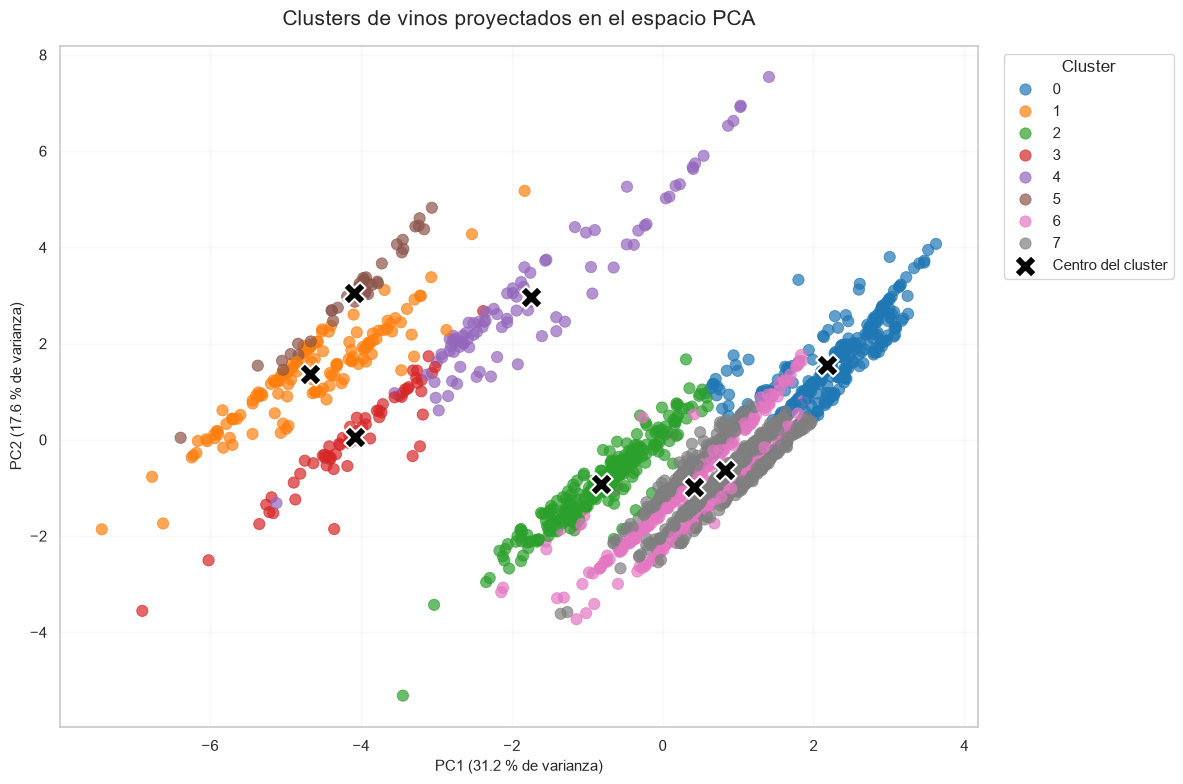

In [11]:
# Calculamos el centro de cada cluster en el espacio formado por PC1 y PC2
cluster_centers_2d = (
    pca_df
    .groupby("cluster_id")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

# Porcentaje de varianza explicado por los dos componentes representados
pc1_variance = pca_2d.explained_variance_ratio_[0] * 100
pc2_variance = pca_2d.explained_variance_ratio_[1] * 100

# Creamos la figura
plt.figure(figsize=(12, 8))

# Representamos los vinos coloreados según el cluster asignado por K-Means
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster_id",
    palette="tab10",
    alpha=0.70,
    s=65,
    edgecolor=None
)

# Representamos el centro de cada cluster
plt.scatter(
    cluster_centers_2d["PC1"],
    cluster_centers_2d["PC2"],
    marker="X",
    s=260,
    color="black",
    edgecolor="white",
    linewidth=1.5,
    label="Centro del cluster",
    zorder=5
)

plt.title(
    "Clusters de vinos proyectados en el espacio PCA",
    fontsize=15,
    pad=15
)

plt.xlabel(
    f"PC1 ({pc1_variance:.1f} % de varianza)",
    fontsize=11
)

plt.ylabel(
    f"PC2 ({pc2_variance:.1f} % de varianza)",
    fontsize=11
)

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

#### Comparación entre diferentes combinaciones de componentes principales

La representación en dos dimensiones mediante **PC1 y PC2** permite visualizar la mayor parte de la estructura del conjunto de datos, ya que ambos componentes concentran cerca del **49 % de la variabilidad total**.

No obstante, esta proyección puede ocultar parte de la separación existente entre algunos grupos, ya que el algoritmo K-Means realizó el clustering utilizando las **18 variables escaladas utilizadas por el modelo**, no únicamente los dos primeros componentes principales.

Para comprobar si la separación entre los clusters mejora al incorporar más información, representaremos también las combinaciones **PC1-PC3** y **PC2-PC3**. Estas visualizaciones complementan el análisis y permiten comprobar si existen estructuras que no son visibles únicamente con los dos primeros componentes.

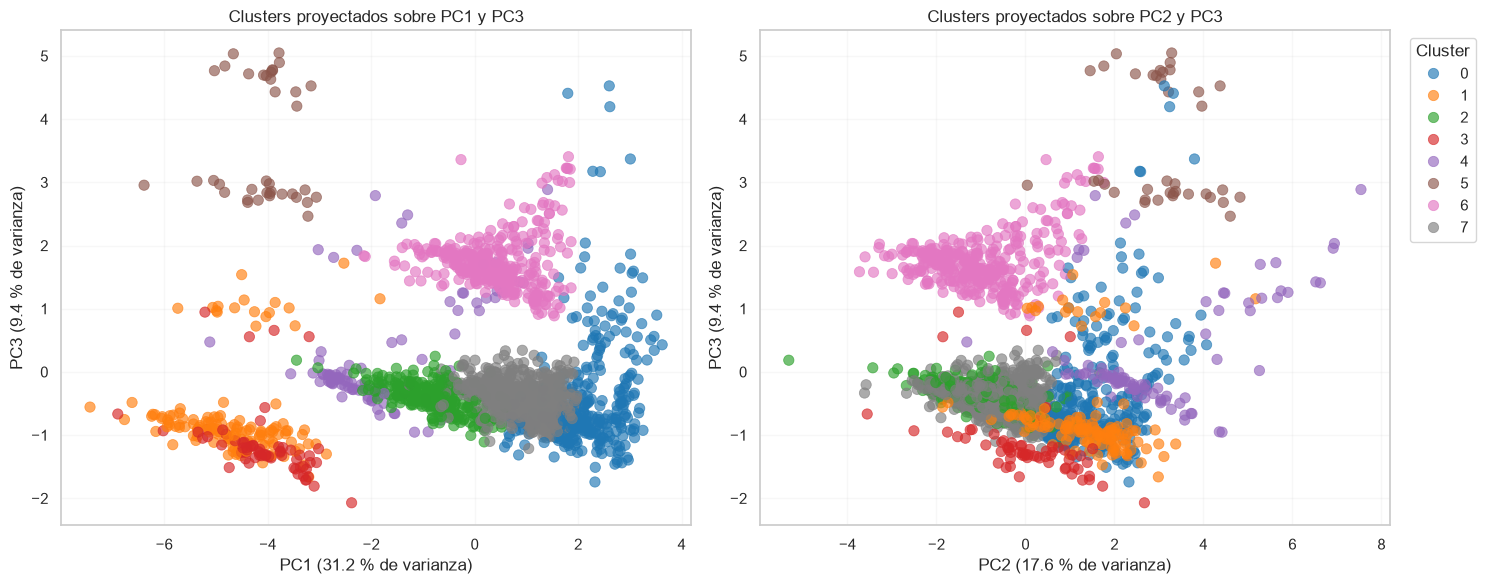

In [12]:
# Proyectamos los vinos sobre los tres primeros componentes principales
pca_3d = PCA(n_components=3)
X_pca_3 = pca_3d.fit_transform(X)

# Creamos un DataFrame con las nuevas coordenadas
pca_3_df = pd.DataFrame(
    X_pca_3,
    columns=["PC1", "PC2", "PC3"]
)

# Incorporamos las etiquetas generadas previamente por K-Means
pca_3_df["cluster_id"] = df_clusters["cluster_id"].to_numpy()

# Porcentaje de varianza explicado por cada componente
pc1_variance = pca_3d.explained_variance_ratio_[0] * 100
pc2_variance = pca_3d.explained_variance_ratio_[1] * 100
pc3_variance = pca_3d.explained_variance_ratio_[2] * 100

# Creamos dos representaciones complementarias
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=pca_3_df,
    x="PC1",
    y="PC3",
    hue="cluster_id",
    palette="tab10",
    alpha=0.65,
    s=55,
    edgecolor=None,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Clusters proyectados sobre PC1 y PC3")
axes[0].set_xlabel(f"PC1 ({pc1_variance:.1f} % de varianza)")
axes[0].set_ylabel(f"PC3 ({pc3_variance:.1f} % de varianza)")
axes[0].grid(alpha=0.15)

sns.scatterplot(
    data=pca_3_df,
    x="PC2",
    y="PC3",
    hue="cluster_id",
    palette="tab10",
    alpha=0.65,
    s=55,
    edgecolor=None,
    ax=axes[1]
)

axes[1].set_title("Clusters proyectados sobre PC2 y PC3")
axes[1].set_xlabel(f"PC2 ({pc2_variance:.1f} % de varianza)")
axes[1].set_ylabel(f"PC3 ({pc3_variance:.1f} % de varianza)")
axes[1].grid(alpha=0.15)

axes[1].legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Interpretación

La comparación entre las proyecciones **PC1-PC3** y **PC2-PC3** confirma que la separación entre algunos clusters mejora al incorporar la tercera componente principal.

En la representación **PC1-PC3** se observa una mayor diferenciación entre varios grupos que en el gráfico PC1-PC2, especialmente en los clusters situados en la parte derecha del espacio. Esto indica que parte de la información utilizada por K-Means para formar los grupos no estaba completamente representada únicamente por las dos primeras componentes.

Por el contrario, la combinación **PC2-PC3** presenta un mayor solapamiento entre algunos clusters, lo que sugiere que la primera componente principal (PC1) es la que aporta una mayor capacidad de discriminación entre los vinos.

En conjunto, estas visualizaciones muestran que la estructura descubierta por K-Means es consistente, aunque la reducción a dos dimensiones implica una pérdida de información respecto al espacio original de 18 variables. Por ello, PCA debe entenderse como una herramienta de visualización e interpretación, y no como una representación exacta del clustering realizado por el modelo.

## 11. Visualización tridimensional de los clusters

Para complementar las proyecciones bidimensionales, representamos simultáneamente las tres primeras componentes principales.

Esta visualización permite observar la distribución de los clusters en un espacio formado por **PC1, PC2 y PC3**, que en conjunto concentran aproximadamente el **58 % de la variabilidad total**.

Aunque sigue siendo una reducción respecto a las 18 variables utilizadas por K-Means, la representación tridimensional conserva más información que los gráficos 2D y puede mostrar separaciones que no resultan visibles en una única proyección plana.

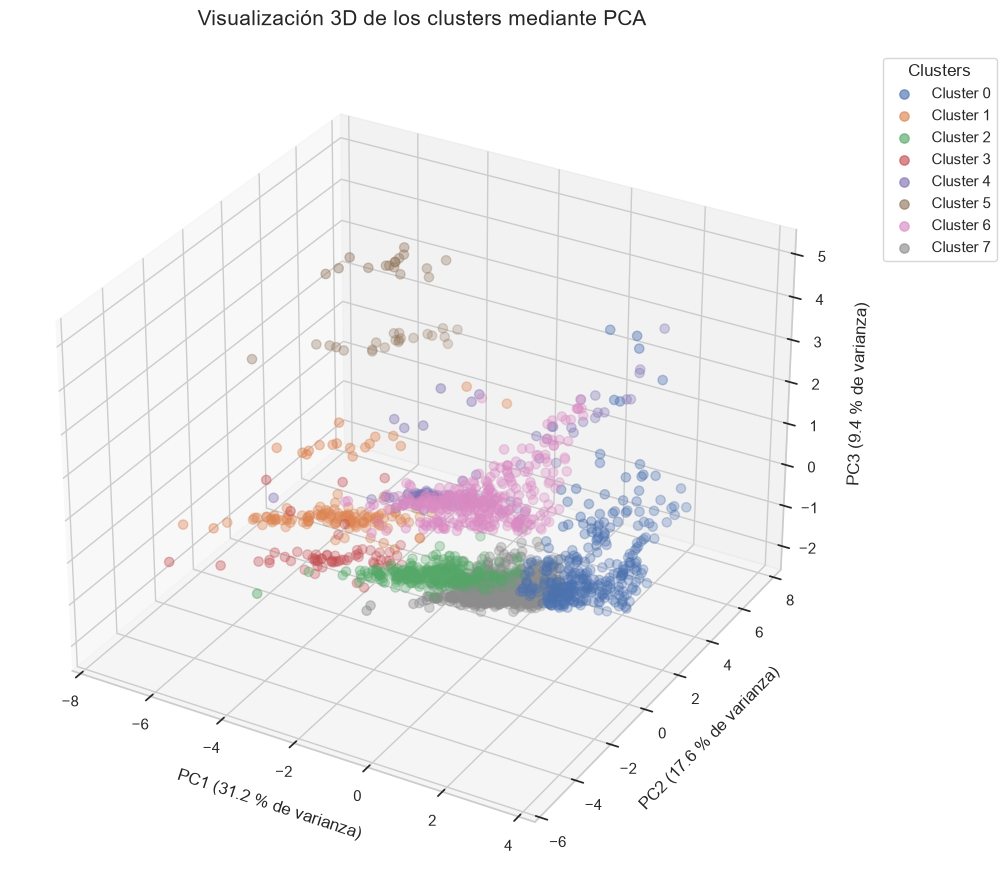

In [13]:
# Creamos una figura tridimensional
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Representamos cada cluster por separado para mantener una leyenda clara
for cluster_id in sorted(pca_3_df["cluster_id"].unique()):
    cluster_data = pca_3_df[pca_3_df["cluster_id"] == cluster_id]

    ax.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        cluster_data["PC3"],
        s=45,
        alpha=0.65,
        label=f"Cluster {cluster_id}"
    )

ax.set_title(
    "Visualización 3D de los clusters mediante PCA",
    fontsize=15,
    pad=18
)

ax.set_xlabel(f"PC1 ({pc1_variance:.1f} % de varianza)", labelpad=10)
ax.set_ylabel(f"PC2 ({pc2_variance:.1f} % de varianza)", labelpad=10)
ax.set_zlabel(f"PC3 ({pc3_variance:.1f} % de varianza)", labelpad=10)

ax.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Interpretación 

La representación tridimensional confirma la estructura general observada en las proyecciones bidimensionales y permite visualizar simultáneamente las tres primeras componentes principales.

Al incorporar **PC1, PC2 y PC3**, se conserva aproximadamente el **58 % de la variabilidad total** del conjunto de datos, proporcionando una representación más completa que las visualizaciones en dos dimensiones.

En esta proyección se aprecia que algunos clusters ocupan regiones claramente diferenciadas del espacio, mientras que otros permanecen próximos entre sí. Este comportamiento es esperable, ya que el modelo K-Means fue entrenado utilizando las **18 variables escaladas** originales y la representación mediante PCA constituye únicamente una proyección de ese espacio de mayor dimensión.

En conjunto, la visualización 3D refuerza que el agrupamiento obtenido por K-Means presenta una estructura coherente y permite comprender mejor la distribución relativa de los distintos grupos de vinos.

## 12. Interpretación de las componentes principales

Tras analizar la distribución de los clusters mediante las proyecciones en dos y tres dimensiones, el siguiente paso consiste en interpretar qué representan las componentes principales obtenidas por PCA.

Además de reducir la dimensionalidad y facilitar la visualización de los clusters, PCA permite identificar qué variables tienen una mayor influencia en cada componente principal.

Estos pesos, conocidos como **loadings**, indican la relación entre las variables escaladas utilizadas por el modelo y cada componente principal:

- Un valor absoluto elevado indica que la variable tiene una influencia importante sobre la componente.
- Un valor positivo o negativo indica la dirección de dicha contribución.
- El signo no implica que una variable sea mejor o peor; simplemente indica el sentido en el que contribuye a la componente y debe interpretarse junto con el resto de variables.

A continuación analizaremos las variables con mayor contribución en **PC1, PC2 y PC3**, ya que son las componentes utilizadas para representar los clusters durante el análisis.

Este estudio permitirá comprender qué características de los vinos explican las principales direcciones de variación detectadas por PCA y ayudan a interpretar la estructura observada en los datos.

In [14]:
# Creamos una tabla con los pesos de cada variable en las componentes principales
loadings = pd.DataFrame(
    pca.components_.T,
    index=scaled_cols,
    columns=[f"PC{i + 1}" for i in range(pca.components_.shape[0])]
)

# Seleccionamos las tres componentes utilizadas en las visualizaciones
loadings_first_components = loadings[["PC1", "PC2", "PC3"]]

loadings_first_components.head()

,PC1,PC2,PC3
year_scaled,-0.162258,-0.347252,-0.384509
rating_scaled,0.212078,0.402343,-0.200755
price_log_scaled,0.309978,0.450751,-0.066432
wine_ageing_scaled,0.023199,-0.088375,0.743232
quality_price_ratio_scaled,-0.306962,-0.386325,0.057084


In [15]:
# Mostramos las variables con mayor influencia en cada componente principal

for pc in ["PC1", "PC2", "PC3"]:

    print(f"\n{'=' * 15} {pc} {'=' * 15}")

    top_variables = (
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .index
    )

    display(
        loadings.loc[top_variables, [pc]].head(10)
    )


=============== PC1 ===============


,PC1
service_temp_midpoint_scaled,0.409797
type_Tinto_scaled,0.401731
grape_variety_encoded_scaled,0.380920
region_encoded_scaled,0.324595
type_Blanco_scaled,-0.310587
price_log_scaled,0.309978
quality_price_ratio_scaled,-0.306962
rating_scaled,0.212078
type_Desconocido_scaled,-0.183015
year_scaled,-0.162258



=============== PC2 ===============


,PC2
price_log_scaled,0.450751
rating_scaled,0.402343
quality_price_ratio_scaled,-0.386325
year_scaled,-0.347252
type_Tinto_scaled,-0.335272
service_temp_midpoint_scaled,-0.315199
type_Generoso_scaled,0.278757
type_Espumoso_scaled,0.184264
type_Blanco_scaled,0.161782
wine_ageing_scaled,-0.088375



=============== PC3 ===============


,PC3
wine_ageing_scaled,0.743232
type_Espumoso_scaled,0.407604
year_scaled,-0.384509
rating_scaled,-0.200755
type_Desconocido_scaled,-0.172814
type_Blanco_scaled,-0.156727
region_encoded_scaled,-0.125930
grape_variety_encoded_scaled,0.101557
price_log_scaled,-0.066432
quality_price_ratio_scaled,0.057084


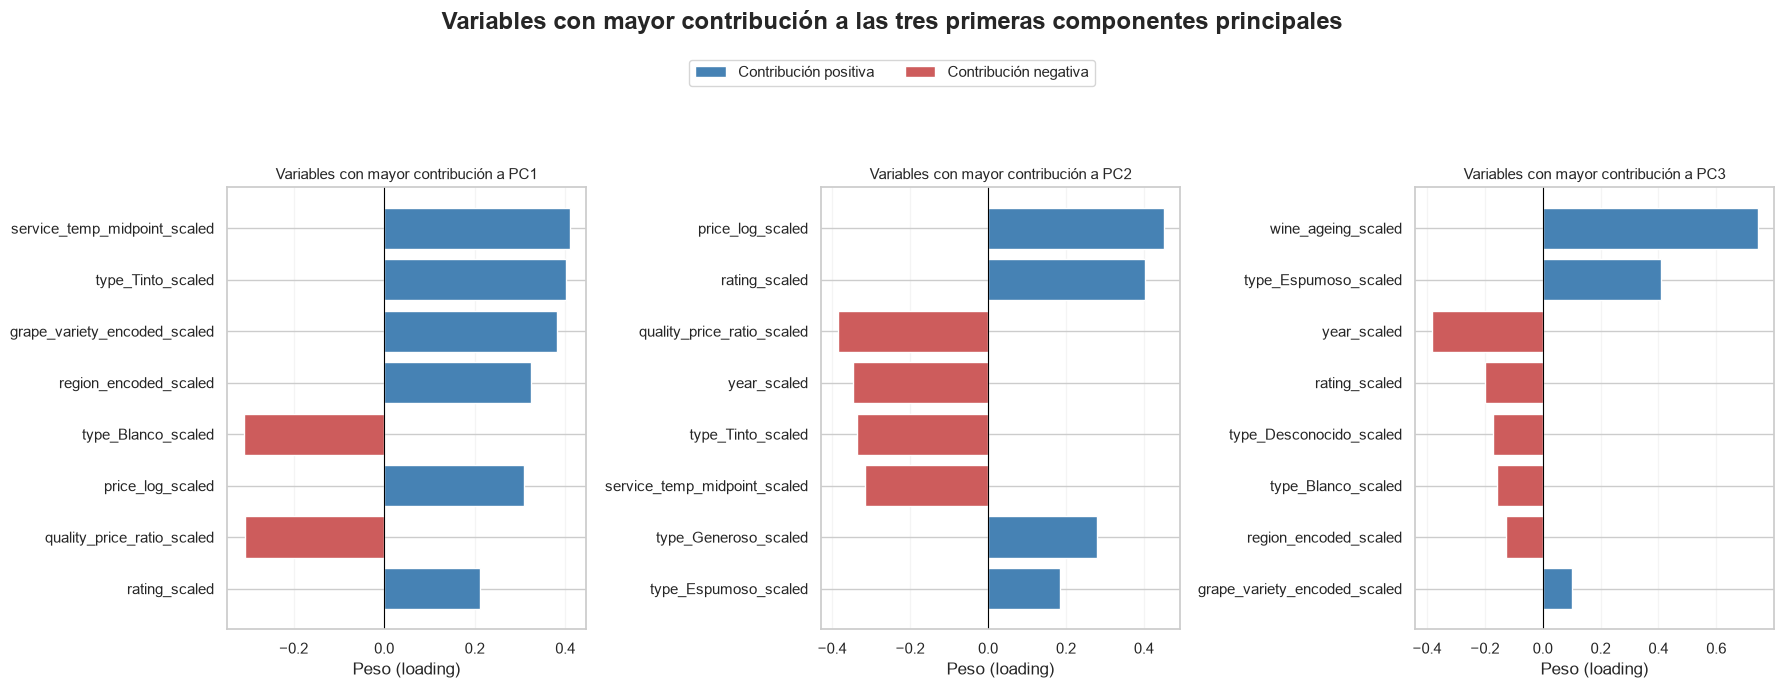

In [16]:
# Número de variables que mostraremos por componente
top_n = 8

# Creamos una figura con un gráfico para cada componente principal
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, pc in zip(axes, ["PC1", "PC2", "PC3"]):

    # Seleccionamos las variables con mayor contribución en valor absoluto
    top_features = (
        loadings[pc]
        .abs()
        .sort_values(ascending=True)
        .tail(top_n)
        .index
    )

    # Conservamos los pesos originales para mantener su dirección
    values = loadings.loc[top_features, pc]

    # Diferenciamos visualmente las contribuciones positivas y negativas
    colors = [
        "steelblue" if value >= 0 else "indianred"
        for value in values
    ]

    ax.barh(
        top_features,
        values,
        color=colors
    )

    # Línea de referencia que separa ambos sentidos de contribución
    ax.axvline(
        x=0,
        color="black",
        linewidth=0.8
    )

    ax.set_title(
        f"Variables con mayor contribución a {pc}",
        fontsize=11
    )

    ax.set_xlabel("Peso (loading)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)

# Elementos de la leyenda común
legend_elements = [
    Patch(facecolor="steelblue", label="Contribución positiva"),
    Patch(facecolor="indianred", label="Contribución negativa")
]

# Título general de la figura
fig.suptitle(
    "Variables con mayor contribución a las tres primeras componentes principales",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

# Leyenda común situada debajo del título
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    frameon=True
)

# Dejamos espacio superior para el título y la leyenda
plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()

#### Interpretación de las componentes principales

Los gráficos anteriores muestran qué variables tienen una mayor contribución a cada una de las tres primeras componentes principales.

- **PC1** está principalmente asociada con la temperatura de servicio, el tipo de vino, la variedad de uva y la región. También intervienen el precio y la relación calidad-precio. Por tanto, esta componente parece recoger diferencias relacionadas con el perfil general del vino, su procedencia y algunas de sus características comerciales.

- **PC2** está dominada por el precio, la valoración (*rating*) y la relación calidad-precio. Estas variables contribuyen en sentidos opuestos dentro de la componente, lo que sugiere que PC2 diferencia principalmente el posicionamiento comercial del vino y su calidad percibida.

- **PC3** está fuertemente condicionada por el envejecimiento del vino (*wine_ageing*), seguido del tipo espumoso y del año de elaboración. Esta componente parece recoger diferencias relacionadas con la maduración, la antigüedad y determinadas características del proceso de elaboración.

Es importante destacar que las variables presentan pesos positivos y negativos. El signo indica únicamente la dirección en la que cada variable contribuye a la componente principal y **no significa que una variable sea más o menos importante por ser positiva o negativa**. La influencia se interpreta a partir del valor absoluto del peso.

En conjunto, las tres primeras componentes muestran que la estructura observada no depende de una sola característica, sino de la combinación de variables relacionadas con el tipo de vino, su procedencia, su elaboración, su valoración y su posicionamiento comercial.

## 13. Conclusiones del análisis mediante PCA

El Análisis de Componentes Principales (PCA) ha permitido resumir la información contenida en las **18 variables escaladas** utilizadas por el modelo de clustering, facilitando tanto su visualización como su interpretación.

Las dos primeras componentes principales explican conjuntamente aproximadamente el **49 % de la variabilidad total**, mientras que las tres primeras alcanzan cerca del **58 %**. Aunque esta reducción implica una pérdida de información respecto al espacio original, resulta suficiente para identificar la estructura general de los datos y analizar el comportamiento de los clusters.

Las representaciones **PC1-PC2**, **PC1-PC3**, **PC2-PC3** y la visualización **3D** muestran que algunos grupos permanecen claramente diferenciados, mientras que otros presentan cierto solapamiento dependiendo de la proyección utilizada. Este comportamiento es esperable, ya que K-Means realizó el agrupamiento utilizando las **18 variables originales escaladas** y no únicamente las tres componentes principales.

El análisis de los **loadings** ha permitido identificar qué variables tienen una mayor influencia en cada componente principal. En este conjunto de datos destacan especialmente variables relacionadas con la **temperatura de servicio**, el **tipo de vino**, la **variedad de uva**, la **región**, el **precio**, la **valoración** y el **envejecimiento**, que son las que más contribuyen a explicar la variabilidad observada.

En conjunto, PCA ha demostrado ser una herramienta muy útil para interpretar el resultado del clustering y comprender mejor la estructura del conjunto de vinos. No obstante, debe entenderse como una técnica de reducción de dimensionalidad y visualización, y no como un sustituto del análisis realizado por K-Means en el espacio original de variables.